🚀 [Setup] 資料切分完成。Test Set 固定為 4706 筆。

🤖 [Model 1] Training Hybrid RoBERTa (Original Data)...
   ✅ Hybrid RoBERTa 預測完成。

🤖 [Model 2] Training Self-Training MacBERT...
   Clean Data: 18821 -> 7910
   ✅ Self-Training MacBERT 預測完成。

🔗 [Ensemble] 執行加權投票...

🏆 【 Ensemble Model (Hybrid + Self-Training) 結果 】
Metric          | Score     
------------------------------
Accuracy        | 0.6849
Precision       | 0.5575
Recall          | 0.4723
F1-Score        | 0.5114
AUROC           | 0.7368
------------------------------
5-Fold F1       | N/A (Ensemble)


📌 模型詳細報告：Ensemble (Th=0.30)
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.7384    0.7989    0.7674      3063
           1     0.5575    0.4723    0.5114      1643

    accuracy                         0.6849      4706
   macro avg     0.6479    0.6356    0.6394      4706
weighted avg     0.6752    0.6849    0.6780      4706

----------

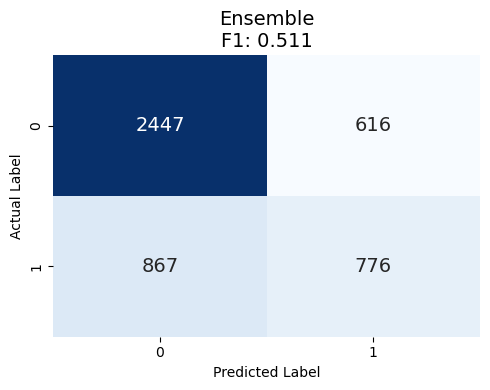

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import os
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW 

# 參數設定
INPUT_CSV = 'News_Data_cleaned.csv'
MAX_LEN = 256; BATCH_SIZE = 32; EPOCHS = 3; LEARNING_RATE = 2e-5; SEED = 42; CV_FOLDS = 5
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
def set_seed(s=42): np.random.seed(s); torch.manual_seed(s); 
set_seed(SEED)

# 共用類別
class HybridDataset(Dataset):
    def __init__(self, texts, extra, labels, tokenizer, max_len):
        self.texts = texts; self.extra = extra; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        enc = self.tokenizer.encode_plus(str(self.texts[item]), add_special_tokens=True, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].flatten(), 'attention_mask': enc['attention_mask'].flatten(), 'extra': torch.tensor(self.extra[item], dtype=torch.float32), 'labels': torch.tensor(self.labels[item], dtype=torch.long)}

class HybridModel(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.cls = nn.Sequential(nn.Linear(768+3, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_labels))
    def forward(self, ids, mask, extra): return self.cls(torch.cat((self.bert(ids, mask).pooler_output, extra), dim=1))

def train_one_epoch(model, loader, opt, dev, sch, w=None):
    model.train(); crit = nn.CrossEntropyLoss(weight=w) if w is not None else nn.CrossEntropyLoss()
    for d in loader:
        opt.zero_grad(); loss = crit(model(d['input_ids'].to(dev), d['attention_mask'].to(dev), d['extra'].to(dev)), d['labels'].to(dev))
        loss.backward(); opt.step(); sch.step()

def get_probs(model, loader, dev):
    model.eval(); probs = []
    with torch.no_grad():
        for d in loader: probs.extend(torch.softmax(model(d['input_ids'].to(dev), d['attention_mask'].to(dev), d['extra'].to(dev)), dim=1)[:, 1].cpu().numpy())
    return np.array(probs)

# 主流程
if not os.path.exists(INPUT_CSV): exit()
df = pd.read_csv(INPUT_CSV)
if 'title_clean' not in df.columns: df['title_clean'] = df['title'].astype(str)
df = df.dropna(subset=['title_clean', 'label']); df['label'] = df['label'].astype(int)

def extract_features(df):
    t = df['title_clean'].astype(str).tolist(); f = []
    for x in t: f.append([len(x), x.count('!')+x.count('！'), 1 if re.search(r'\d', x) else 0])
    return MinMaxScaler().fit_transform(np.array(f))

# 1. 統一的 80/20 切分 (確保兩個模型測試集一致)
X_txt = df['title_clean'].values
X_stats = extract_features(df)
y = df['label'].values
# 保存索引以追蹤
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=SEED, stratify=y)

print(f"🚀 [Setup] 資料切分完成。Test Set 固定為 {len(test_idx)} 筆。")

# ============================
# Model 1: Hybrid RoBERTa (廣度)
# ============================
print("\n🤖 [Model 1] Training Hybrid RoBERTa (Original Data)...")
MODEL_1 = 'hfl/chinese-roberta-wwm-ext'
tok1 = BertTokenizer.from_pretrained(MODEL_1)

# 訓練集 (Original)
ds_tr_1 = HybridDataset(X_txt[train_idx], X_stats[train_idx], y[train_idx], tok1, MAX_LEN)
ld_tr_1 = DataLoader(ds_tr_1, BATCH_SIZE, shuffle=True)
# 測試集
ds_te_1 = HybridDataset(X_txt[test_idx], X_stats[test_idx], y[test_idx], tok1, MAX_LEN)
ld_te_1 = DataLoader(ds_te_1, BATCH_SIZE)

# 計算權重
y_tr = y[train_idx]
w = torch.tensor([len(y_tr)/(2*sum(y_tr==0)), len(y_tr)/(2*sum(y_tr==1))], dtype=torch.float32).to(DEVICE)

model1 = HybridModel(MODEL_1).to(DEVICE)
opt1 = AdamW(model1.parameters(), lr=LEARNING_RATE)
sch1 = get_linear_schedule_with_warmup(opt1, 0, len(ld_tr_1)*EPOCHS)

for ep in range(EPOCHS): train_one_epoch(model1, ld_tr_1, opt1, DEVICE, sch1, w)
probs1 = get_probs(model1, ld_te_1, DEVICE)
print("   ✅ Hybrid RoBERTa 預測完成。")
del model1; gc.collect(); torch.mps.empty_cache() if torch.backends.mps.is_available() else None

# ============================
# Model 2: Self-Training (精度)
# ============================
print("\n🤖 [Model 2] Training Self-Training MacBERT...")
MODEL_2 = 'hfl/chinese-macbert-base'
tok2 = BertTokenizer.from_pretrained(MODEL_2)

# Teacher: Train on Original Train Set
model2t = HybridModel(MODEL_2).to(DEVICE)
ds_tr_2 = HybridDataset(X_txt[train_idx], X_stats[train_idx], y[train_idx], tok2, MAX_LEN)
ld_tr_2 = DataLoader(ds_tr_2, BATCH_SIZE, shuffle=True)
ld_pred_2 = DataLoader(ds_tr_2, BATCH_SIZE, shuffle=False)
opt2 = AdamW(model2t.parameters(), lr=LEARNING_RATE)
sch2 = get_linear_schedule_with_warmup(opt2, 0, len(ld_tr_2)*EPOCHS)

for ep in range(EPOCHS): train_one_epoch(model2t, ld_tr_2, opt2, DEVICE, sch2)
# Filter
tr_probs = get_probs(model2t, ld_pred_2, DEVICE)
clean_mask = (tr_probs > 0.8) | (tr_probs < 0.2)
clean_train_idx = train_idx[clean_mask] # 這些是原始訓練集中被保留的
print(f"   Clean Data: {len(train_idx)} -> {len(clean_train_idx)}")
del model2t; gc.collect()

# Student: Train on Clean Train Set
ds_st_2 = HybridDataset(X_txt[clean_train_idx], X_stats[clean_train_idx], y[clean_train_idx], tok2, MAX_LEN)
ld_st_2 = DataLoader(ds_st_2, BATCH_SIZE, shuffle=True)
# Evaluate on ORIGINAL Test Set (重要！要跟 Model 1 對齊)
ds_te_2 = HybridDataset(X_txt[test_idx], X_stats[test_idx], y[test_idx], tok2, MAX_LEN)
ld_te_2 = DataLoader(ds_te_2, BATCH_SIZE)

model2s = HybridModel(MODEL_2).to(DEVICE)
opt2s = AdamW(model2s.parameters(), lr=LEARNING_RATE)
sch2s = get_linear_schedule_with_warmup(opt2s, 0, len(ld_st_2)*EPOCHS)

for ep in range(EPOCHS): train_one_epoch(model2s, ld_st_2, opt2s, DEVICE, sch2s)
probs2 = get_probs(model2s, ld_te_2, DEVICE)
print("   ✅ Self-Training MacBERT 預測完成。")
del model2s; gc.collect()

# ============================
# Ensemble
# ============================
print("\n🔗 [Ensemble] 執行加權投票...")
# 策略：讓 Self-Training (高精度) 權重稍高，但 Hybrid (高召回) 負責打底
final_probs = (probs1 * 0.4) + (probs2 * 0.6)
y_test = y[test_idx]

best_f1, best_th = 0, 0.5
for th in np.arange(0.3, 0.8, 0.01):
    f1 = f1_score(y_test, (final_probs>=th).astype(int))
    if f1 > best_f1: best_f1, best_th = f1, th
y_final_pred = (final_probs >= best_th).astype(int)

# 輸出結果
print("\n" + "="*80)
print(f"🏆 【 Ensemble Model (Hybrid + Self-Training) 結果 】")
print("="*80)
print(f"{'Metric':<15} | {'Score':<10}")
print("-" * 30)
print(f"{'Accuracy':<15} | {accuracy_score(y_test, y_final_pred):.4f}")
print(f"{'Precision':<15} | {precision_score(y_test, y_final_pred):.4f}")
print(f"{'Recall':<15} | {recall_score(y_test, y_final_pred):.4f}")
print(f"{'F1-Score':<15} | {best_f1:.4f}")
print(f"{'AUROC':<15} | {roc_auc_score(y_test, final_probs):.4f}")
print("-" * 30)
# Ensemble 無法直接計算 5-Fold F1 (因運算量過大)，顯示 N/A
print(f"{'5-Fold F1':<15} | {'N/A (Ensemble)':<10}") 
print("\n")

print("="*80)
print(f"📌 模型詳細報告：Ensemble (Th={best_th:.2f})")
print("-" * 80)
print(classification_report(y_test, y_final_pred, digits=4))
print("-" * 80)

cm = confusion_matrix(y_test, y_final_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title(f'Ensemble\nF1: {best_f1:.3f}', fontsize=14)
plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()